# SPY Hybrid QRNN SI Self-lagged

Original unrestricted model tuning with seven separately estimated quantile levels and rank-based model selection.

In [2]:
# ============================================================
# SPY MODELLING DATA PREPARATION
# Common setup for all ERNN and QRNN specifications
# ============================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Reproducibility and device
# ------------------------------------------------------------

BASE_SEED = 2026

random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BASE_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# 2. Load the scaled SPY dataset
# ------------------------------------------------------------

DATA_PATH = Path.home() / "SPY_features_scaled.csv"

df = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=True
)

df = (
    df
    .sort_index()
    .drop_duplicates()
    .dropna()
    .copy()
)


# ------------------------------------------------------------
# 3. Response and predictors
# ------------------------------------------------------------

target_col = "log_return"

feature_cols = [
    "Volatility",
    "RSI_14",
    "ATR_14",
    "QQQ_LogReturns",
    "VIX_LogChange",
    "Volume_LogChange",
]

required_cols = [target_col] + feature_cols

missing_cols = [
    column
    for column in required_cols
    if column not in df.columns
]

if missing_cols:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_cols)
    )


# ------------------------------------------------------------
# 4. Chronological 70%-15%-15% split
# ------------------------------------------------------------

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()


# ------------------------------------------------------------
# 5. Convert samples to tensors
# ------------------------------------------------------------

def dataframe_to_tensors(sample):
    X = torch.tensor(
        sample[feature_cols].to_numpy(),
        dtype=torch.float32,
        device=device
    )
    y = torch.tensor(
        sample[target_col].to_numpy(),
        dtype=torch.float32,
        device=device
    )
    return X, y


X_train, y_train = dataframe_to_tensors(train_df)
X_val, y_val = dataframe_to_tensors(val_df)
X_test, y_test = dataframe_to_tensors(test_df)

# Compatibility aliases used by later QRNN cells.
X_test_q = X_test
y_test_q = y_test

levels = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

alpha_levels = levels
tau_levels = levels


# ------------------------------------------------------------
# 6. Checks and split summary
# ------------------------------------------------------------

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)
assert X_train.shape[1] == len(feature_cols)
assert torch.isfinite(X_train).all()
assert torch.isfinite(X_val).all()
assert torch.isfinite(X_test).all()
assert torch.isfinite(y_train).all()
assert torch.isfinite(y_val).all()
assert torch.isfinite(y_test).all()

split_summary = pd.DataFrame({
    "Sample": ["Training", "Validation", "Test"],
    "Observations": [len(train_df), len(val_df), len(test_df)],
    "Start": [
        train_df.index.min().date(),
        val_df.index.min().date(),
        test_df.index.min().date(),
    ],
    "End": [
        train_df.index.max().date(),
        val_df.index.max().date(),
        test_df.index.max().date(),
    ],
})

display(split_summary)

print("Input features:", feature_cols)
print("Number of predictors:", len(feature_cols))
print("X_train shape:", tuple(X_train.shape))
print("X_val shape:  ", tuple(X_val.shape))
print("X_test shape: ", tuple(X_test.shape))


Device: cpu


,Sample,Observations,Start,End
0,Training,2219,2014-01-23,2022-11-11
1,Validation,475,2022-11-14,2024-10-04
2,Test,476,2024-10-07,2026-08-31


Input features: ['Volatility', 'RSI_14', 'ATR_14', 'QQQ_LogReturns', 'VIX_LogChange', 'Volume_LogChange']
Number of predictors: 6
X_train shape: (2219, 6)
X_val shape:   (475, 6)
X_test shape:  (476, 6)


## Original tuning

Run after the preparation cell.

In [6]:
# ============================================================
# ORIGINAL TUNING — SPY HYBRID QRNN SI SELF-LAGGED
# Seven separately estimated levels; 200 Optuna trials per level
# ============================================================

import copy
import json
import time

import optuna
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


MODEL_NAME = "spy_qrnn_si_self"
FORM = "SI"
LAG_TYPE = "self"
N_TRIALS = 200
MAX_EPOCHS = 200

ALPHA_LEVELS = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975,
]

OUTPUT_DIR = Path("spy_original_tuning_results") / MODEL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Output directory:", OUTPUT_DIR.resolve())


def set_model_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def hybrid_qrnn_loss(y, q_hybrid, sigma_al, alpha):
    """Mean asymmetric-Laplace negative log-likelihood."""
    eps = torch.finfo(q_hybrid.dtype).eps
    sigma_al = torch.clamp(sigma_al, min=eps)
    alpha_tensor = torch.as_tensor(
        alpha,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )
    residual = y - q_hybrid
    indicator = (residual < 0).to(q_hybrid.dtype)
    check_loss = residual * (alpha_tensor - indicator)
    nll = (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma_al)
        + check_loss / sigma_al
    )
    return nll.mean()


def compute_hybrid_location(y, X, beta1, beta2, beta3, fnn, psi):
    """SI-form self-lagged CAViaR-hybrid recursion."""
    fnn_output = fnn(X).squeeze(-1)
    zero_value = y.new_zeros(())
    statistical_forecasts = [zero_value]
    hybrid_forecasts = [zero_value]

    for time_index in range(1, len(y)):
        previous_return = y[time_index - 1]
        previous_state = statistical_forecasts[time_index - 1]
        absolute_return = torch.abs(previous_return)
        statistical_value = (
            beta1 * previous_state
            + beta2 * absolute_return
            + beta3 * previous_state * absolute_return
        )
        hybrid_value = (
            psi * statistical_value
            + (1.0 - psi) * fnn_output[time_index]
        )
        statistical_forecasts.append(statistical_value)
        hybrid_forecasts.append(hybrid_value)

    return (
        torch.stack(hybrid_forecasts),
        torch.stack(statistical_forecasts),
    )


class HybridQRNN_SI_Self(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()
        self.eps = 1e-6
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.beta3_raw = nn.Parameter(
            torch.tensor(0.3)
        )
        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        layers = []
        previous_dimension = input_dim
        for layer_index in range(config["n_hidden_layers"]):
            hidden_dimension = config[f"hidden_dim_{layer_index}"]
            layers.append(nn.Linear(previous_dimension, hidden_dimension))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dimension))
            layers.append(self.get_activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dimension = hidden_dimension
        layers.append(nn.Linear(previous_dimension, 1))
        self.fnn = nn.Sequential(*layers)
        self.initialise_weights(config["weight_init"])

    @staticmethod
    def get_activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def initialise_weights(self, method):
        for module in self.fnn.modules():
            if not isinstance(module, nn.Linear):
                continue
            if method == "glorot":
                nn.init.xavier_uniform_(module.weight)
            else:
                nn.init.kaiming_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(
            self.beta3_raw
        )
        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps
        hybrid, statistical = compute_hybrid_location(
            y, X, beta1, beta2, beta3, self.fnn, psi
        )
        return hybrid, sigma, statistical


def calculate_crp(y, forecast, alpha):
    if alpha <= 0.5:
        empirical = (y <= forecast).float().mean().item()
        target = alpha
    else:
        empirical = (y > forecast).float().mean().item()
        target = 1.0 - alpha
    crp = empirical / target
    return crp, (crp - 1.0) ** 2, empirical


def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical(
            "activation", ["relu", "elu", "gelu", "tanh"]
        ),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical(
            "weight_init", ["glorot", "he"]
        ),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical(
            "optimizer", ["adam", "adamw"]
        ),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical(
            "gradient_clip", [0.1, 1.0, 5.0]
        ),
        "patience": trial.suggest_categorical(
            "patience", [10, 20, 30]
        ),
    }
    for layer_index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{layer_index}"] = trial.suggest_int(
            f"hidden_dim_{layer_index}", 32, 256
        )
    return config


def make_optimizer(model, config):
    arguments = {
        "params": model.parameters(),
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
    }
    if config["optimizer"] == "adam":
        return torch.optim.Adam(**arguments)
    return torch.optim.AdamW(**arguments)


def train_configuration(config, alpha, model_seed=BASE_SEED):
    set_model_seed(model_seed)
    model = HybridQRNN_SI_Self(X_train.shape[1], config).to(device)
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=10,
        factor=0.5,
        min_lr=1e-6,
    )
    best_nll = np.inf
    best_state = None
    patience_counter = 0
    epochs_completed = 0

    for epoch in range(MAX_EPOCHS):
        epochs_completed = epoch + 1
        model.train()
        optimizer.zero_grad()
        train_forecast, train_sigma, _ = model(y_train, X_train)
        train_loss = hybrid_qrnn_loss(
            y_train, train_forecast, train_sigma, alpha
        )
        if not torch.isfinite(train_loss):
            return None
        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config["gradient_clip"]
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            validation_forecast, validation_sigma, _ = model(y_val, X_val)
            validation_loss = hybrid_qrnn_loss(
                y_val, validation_forecast, validation_sigma, alpha
            )
        if not torch.isfinite(validation_loss):
            return None
        scheduler.step(validation_loss)
        current_nll = validation_loss.item()
        if current_nll < best_nll:
            best_nll = current_nll
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        validation_forecast, validation_sigma, _ = model(y_val, X_val)
        validation_nll = hybrid_qrnn_loss(
            y_val, validation_forecast, validation_sigma, alpha
        ).item()
        crp, crp_penalty, hit_rate = calculate_crp(
            y_val, validation_forecast, alpha
        )
    parameters = {
        "beta1": torch.sigmoid(model.beta1_raw).item(),
        "beta2": F.softplus(model.beta2_raw).item(),
        "beta3": (
            F.softplus(model.beta3_raw).item()
            if model.beta3_raw is not None
            else np.nan
        ),
        "psi": torch.sigmoid(model.psi_raw).item(),
        "sigma": (F.softplus(model.sigma_raw) + model.eps).item(),
    }
    return {
        "model": model,
        "validation_nll": validation_nll,
        "validation_crp": crp,
        "validation_crp_penalty": crp_penalty,
        "validation_hit_rate": hit_rate,
        "epochs_completed": epochs_completed,
        **parameters,
    }


def objective(trial, alpha):
    config = suggest_config(trial)
    result = train_configuration(config, alpha)
    if result is None:
        raise optuna.TrialPruned("Non-finite loss or no valid checkpoint.")
    for name in [
        "validation_nll", "validation_crp", "validation_crp_penalty",
        "validation_hit_rate", "epochs_completed", "beta1", "beta2",
        "beta3", "psi", "sigma",
    ]:
        trial.set_user_attr(name, result[name])
    return result["validation_nll"]


def rank_trials(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "validation_crp_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    nll_order = sorted(
        trials, key=lambda trial: trial.user_attrs["validation_nll"]
    )
    crp_order = sorted(
        trials,
        key=lambda trial: trial.user_attrs["validation_crp_penalty"],
    )
    nll_rank = {trial.number: rank for rank, trial in enumerate(nll_order, 1)}
    crp_rank = {trial.number: rank for rank, trial in enumerate(crp_order, 1)}
    records = []
    for trial in trials:
        record = {
            "trial": trial.number,
            **trial.user_attrs,
            "rank_nll": nll_rank[trial.number],
            "rank_crp": crp_rank[trial.number],
            "sum_rank": nll_rank[trial.number] + crp_rank[trial.number],
            **trial.params,
        }
        records.append(record)
    table = pd.DataFrame(records).sort_values(
        [
            "sum_rank",
            "validation_nll",
            "validation_crp_penalty",
            "trial",
        ]
    ).reset_index(drop=True)
    selected_number = int(table.iloc[0]["trial"])
    selected_trial = next(
        trial for trial in trials if trial.number == selected_number
    )
    return selected_trial, table


best_configs_spy_qrnn_si_self = {}
best_models_spy_qrnn_si_self = {}
summary_records = []
overall_start = time.time()

for level_index, alpha in enumerate(ALPHA_LEVELS):
    level_start = time.time()
    sampler_seed = BASE_SEED + level_index
    print("\n" + "=" * 72)
    print(f"Tuning {MODEL_NAME} at alpha={alpha:.3f}")
    print(f"Trials={N_TRIALS} | sampler seed={sampler_seed}")
    print("=" * 72)

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=sampler_seed),
        study_name=f"{MODEL_NAME}_alpha_{alpha:.3f}",
    )
    study.optimize(
        lambda trial, current_alpha=alpha: objective(trial, current_alpha),
        n_trials=N_TRIALS,
        show_progress_bar=True,
        gc_after_trial=True,
    )
    selected_trial, ranking_table = rank_trials(study)
    alpha_label = f"{alpha:.3f}"
    ranking_table.insert(0, "alpha", alpha)
    ranking_path = OUTPUT_DIR / (
        f"{MODEL_NAME}_ranking_alpha_{alpha_label}.csv"
    )
    ranking_table.to_csv(ranking_path, index=False)

    selected_config = selected_trial.params.copy()
    selected_result = train_configuration(selected_config, alpha)
    if selected_result is None:
        raise RuntimeError(
            f"Selected trial could not be reproduced for alpha={alpha}."
        )
    selected_model = selected_result["model"]
    checkpoint_path = OUTPUT_DIR / (
        f"{MODEL_NAME}_best_alpha_{alpha_label}.pt"
    )
    torch.save(
        {
            "model_name": MODEL_NAME,
            "asset": "SPY",
            "form": FORM,
            "lag_type": LAG_TYPE,
            "alpha": alpha,
            "selected_trial": selected_trial.number,
            "config": selected_config,
            "model_state_dict": {
                key: value.detach().cpu()
                for key, value in selected_model.state_dict().items()
            },
            "validation_nll": selected_result["validation_nll"],
            "validation_crp": selected_result["validation_crp"],
            "validation_crp_penalty": selected_result[
                "validation_crp_penalty"
            ],
            "validation_hit_rate": selected_result["validation_hit_rate"],
            "estimated_parameters": {
                name: selected_result[name]
                for name in ["beta1", "beta2", "beta3", "psi", "sigma"]
            },
            "feature_cols": feature_cols,
            "number_of_trials": N_TRIALS,
            "base_seed": BASE_SEED,
            "sampler_seed": sampler_seed,
        },
        checkpoint_path,
    )
    selected_record = {
        **selected_config,
        "selected_trial": selected_trial.number,
        **{
            name: selected_result[name]
            for name in [
                "validation_nll", "validation_crp",
                "validation_crp_penalty", "validation_hit_rate",
                "beta1", "beta2", "beta3", "psi", "sigma",
            ]
        },
    }
    best_configs_spy_qrnn_si_self[alpha] = selected_record
    best_models_spy_qrnn_si_self[alpha] = selected_model
    runtime_hours = (time.time() - level_start) / 3600
    summary_records.append({
        "alpha": alpha,
        "selected_trial": selected_trial.number,
        "validation_nll": selected_result["validation_nll"],
        "validation_crp": selected_result["validation_crp"],
        "validation_crp_penalty": selected_result[
            "validation_crp_penalty"
        ],
        "validation_hit_rate": selected_result["validation_hit_rate"],
        "beta1": selected_result["beta1"],
        "beta2": selected_result["beta2"],
        "beta3": selected_result["beta3"],
        "psi": selected_result["psi"],
        "sigma": selected_result["sigma"],
        "valid_trials": len(ranking_table),
        "runtime_hours": runtime_hours,
    })
    print("\nTop 10 rank-based trials:")
    print(ranking_table[[
        "trial", "validation_nll", "validation_crp",
        "validation_crp_penalty", "rank_nll", "rank_crp", "sum_rank",
    ]].head(10).to_string(index=False))
    print("\nSelected trial:", selected_trial.number)
    print("Validation NLL:", f"{selected_result['validation_nll']:.8f}")
    print("Validation CRP:", f"{selected_result['validation_crp']:.8f}")
    print("Ranking saved to:", ranking_path)
    print("Checkpoint saved to:", checkpoint_path)


summary_spy_qrnn_si_self = pd.DataFrame(summary_records)
summary_path = OUTPUT_DIR / f"{MODEL_NAME}_tuning_summary.csv"
summary_spy_qrnn_si_self.to_csv(summary_path, index=False)

config_path = OUTPUT_DIR / f"{MODEL_NAME}_selected_configs.json"
with open(config_path, "w") as configuration_file:
    json.dump(
        {f"{alpha:.3f}": config for alpha, config in best_configs_spy_qrnn_si_self.items()},
        configuration_file,
        indent=2,
    )

print("\n" + "=" * 72)
print("SPY ORIGINAL TUNING COMPLETED:", MODEL_NAME)
print("=" * 72)
display(summary_spy_qrnn_si_self)
print("Total runtime (hours):", f"{(time.time() - overall_start) / 3600:.3f}")
print("Summary saved to:", summary_path)
print("Selected configurations saved to:", config_path)


[I 2026-09-15 11:05:53,398] A new study created in memory with name: spy_qrnn_si_self_alpha_0.025


Model: spy_qrnn_si_self
Output directory: /Users/miaomiaochen/Desktop/PhD program/Project 1/spy_original_tuning_results/spy_qrnn_si_self

Tuning spy_qrnn_si_self at alpha=0.025
Trials=200 | sampler seed=2026


  0%|          | 0/200 [00:00<?, ?it/s]

[W 2026-09-15 11:06:00,072] Trial 0 failed with parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/0k/3jhs8p2d2bdd3_fvs731s4cr0000gn/T/ipykernel_16270/4115617181.py", line 367, in <lambda>
    lambda trial, current_alpha=alpha: objective(trial, current_alpha),
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/0k/3jhs8p2d2bdd3_fvs731s4cr0000gn/T/ipykernel_16270/4115617181.py", line 291, in objective
    result = train_configuration(config, alpha)
  

KeyboardInterrupt: 

## Test evaluation and plotting

This section loads the selected checkpoints and does not rerun tuning.

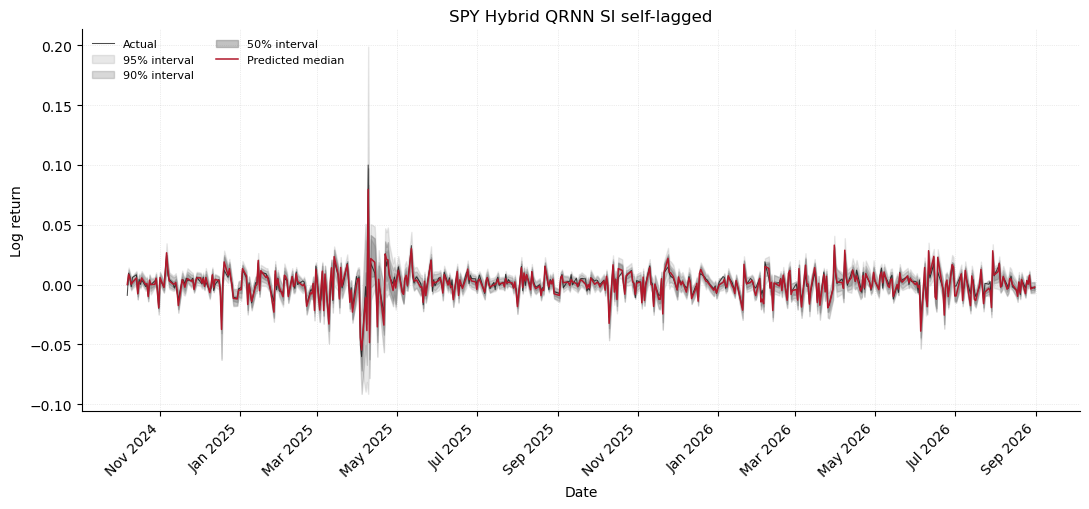


TEST METRICS — SPY HYBRID QRNN SI SELF-LAGGED
 alpha       NLL  Hit_Rate      HRE    Sigma  Selected_Trial
 0.025 -3.550740  0.016807 0.008193 0.000289             186
 0.050 -3.752326  0.027311 0.022689 0.000438             172
 0.250 -4.073911  0.191176 0.058824 0.001129             181
 0.500 -4.215832  0.445378 0.054622 0.001688             183
 0.750 -4.133467  0.735294 0.014706 0.001279             142
 0.950 -3.835139  0.983193 0.033193 0.000460             180
 0.975 -3.710839  0.985294 0.010294 0.000283             179

Average NLL: -3.896036
Average HRE: 0.028932

CROSSOVER ANALYSIS — RAW TEST FORECASTS
 Lower_Alpha  Upper_Alpha  Violations  Violation_Rate  Tail_Pair
       0.025        0.050          84        0.176471       True
       0.050        0.250           0        0.000000      False
       0.250        0.500           9        0.018908      False
       0.500        0.750          13        0.027311      False
       0.750        0.950          14        0.029412

In [10]:
# ============================================================
# TEST EVALUATION AND PLOTTING — SPY HYBRID QRNN SI SELF-LAGGED
# Loads saved checkpoints; does not retune any model
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


EVALUATION_MODEL_NAME = "spy_qrnn_si_self"
EVALUATION_FORM = "SI"
EVALUATION_LAG = "self"

EVALUATION_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

required_evaluation_objects = [
    "X_test",
    "y_test",
    "test_df",
    "device",
]

missing_evaluation_objects = [
    name
    for name in required_evaluation_objects
    if name not in globals()
]

if missing_evaluation_objects:
    raise RuntimeError(
        "Missing SPY preparation objects: "
        + ", ".join(missing_evaluation_objects)
        + "\nRun only the SPY data-preparation cell, then rerun this cell."
    )

EVALUATION_DIR = (
    Path("spy_original_tuning_results")
    / EVALUATION_MODEL_NAME
)

if not EVALUATION_DIR.exists():
    raise FileNotFoundError(
        f"Results directory not found: {EVALUATION_DIR.resolve()}"
    )


# ------------------------------------------------------------
# 1. Self-contained checkpoint-compatible model
# ------------------------------------------------------------

def evaluation_recurrence(
    y,
    X,
    beta1,
    beta2,
    beta3,
    fnn,
    psi,
):
    fnn_output = fnn(X).squeeze(-1)
    zero_value = y.new_zeros(())
    statistical_forecasts = [zero_value]
    hybrid_forecasts = [zero_value]

    for time_index in range(1, len(y)):
        previous_return = y[time_index - 1]

        if EVALUATION_LAG == "self":
            previous_state = statistical_forecasts[time_index - 1]
        else:
            previous_state = hybrid_forecasts[time_index - 1]

        if EVALUATION_FORM == "S":
            statistical_value = (
                beta1 * previous_state
                + beta2 * torch.abs(previous_return)
            )

        elif EVALUATION_FORM == "A":
            positive_return = torch.clamp(previous_return, min=0)
            negative_return = torch.clamp(-previous_return, min=0)
            statistical_value = (
                beta1 * previous_state
                + beta2 * positive_return
                + beta3 * negative_return
            )

        elif EVALUATION_FORM == "SI":
            absolute_return = torch.abs(previous_return)
            statistical_value = (
                beta1 * previous_state
                + beta2 * absolute_return
                + beta3 * previous_state * absolute_return
            )

        else:
            raise ValueError(f"Unknown form: {EVALUATION_FORM}")

        hybrid_value = (
            psi * statistical_value
            + (1.0 - psi) * fnn_output[time_index]
        )

        statistical_forecasts.append(statistical_value)
        hybrid_forecasts.append(hybrid_value)

    return (
        torch.stack(hybrid_forecasts),
        torch.stack(statistical_forecasts),
    )


class EvaluationHybridQRNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.eps = 1e-6
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))

        if EVALUATION_FORM in {"A", "SI"}:
            self.beta3_raw = nn.Parameter(torch.tensor(0.3))
        else:
            self.beta3_raw = None

        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        layers = []
        previous_dimension = input_dim

        for layer_index in range(config["n_hidden_layers"]):
            hidden_dimension = config[f"hidden_dim_{layer_index}"]
            layers.append(nn.Linear(previous_dimension, hidden_dimension))

            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dimension))

            activation = {
                "relu": nn.ReLU(),
                "elu": nn.ELU(),
                "gelu": nn.GELU(),
                "tanh": nn.Tanh(),
            }[config["activation"]]

            layers.append(activation)

            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))

            previous_dimension = hidden_dimension

        layers.append(nn.Linear(previous_dimension, 1))
        self.fnn = nn.Sequential(*layers)

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)

        beta3 = (
            F.softplus(self.beta3_raw)
            if self.beta3_raw is not None
            else None
        )

        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        hybrid_forecast, statistical_forecast = evaluation_recurrence(
            y=y,
            X=X,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            fnn=self.fnn,
            psi=psi,
        )

        return hybrid_forecast, sigma, statistical_forecast


# ------------------------------------------------------------
# 2. Evaluation functions
# ------------------------------------------------------------

def evaluation_ald_nll(y, forecast, sigma, alpha):
    sigma = torch.clamp(
        sigma,
        min=torch.finfo(forecast.dtype).eps,
    )

    alpha_tensor = torch.as_tensor(
        alpha,
        dtype=forecast.dtype,
        device=forecast.device,
    )

    residual = y - forecast
    indicator = (residual < 0).to(forecast.dtype)
    check_loss = residual * (alpha_tensor - indicator)

    observation_nll = (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    )

    return observation_nll


# ------------------------------------------------------------
# 3. Load each selected checkpoint and forecast the test sample
# ------------------------------------------------------------

test_forecast_columns = []
test_nll_columns = []
test_metric_records = []
loaded_test_models = {}

for alpha in EVALUATION_LEVELS:
    alpha_label = f"{alpha:.3f}"

    checkpoint_path = EVALUATION_DIR / (
        f"{EVALUATION_MODEL_NAME}_best_alpha_{alpha_label}.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint: {checkpoint_path.resolve()}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model = EvaluationHybridQRNN(
        input_dim=X_test.shape[1],
        config=checkpoint["config"],
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    with torch.no_grad():
        forecast, sigma, _ = model(y_test, X_test)

        observation_nll = evaluation_ald_nll(
            y=y_test,
            forecast=forecast,
            sigma=sigma,
            alpha=alpha,
        )

    forecast_np = forecast.detach().cpu().numpy()
    nll_np = observation_nll.detach().cpu().numpy()
    y_test_np = y_test.detach().cpu().numpy()

    hit_rate = float(np.mean(y_test_np <= forecast_np))
    hre = abs(hit_rate - alpha)

    test_forecast_columns.append(forecast_np)
    test_nll_columns.append(nll_np)
    loaded_test_models[alpha] = model

    test_metric_records.append({
        "alpha": alpha,
        "NLL": float(np.mean(nll_np)),
        "Hit_Rate": hit_rate,
        "HRE": hre,
        "Sigma": float(sigma.detach().cpu().item()),
        "Selected_Trial": checkpoint["selected_trial"],
    })


test_forecast_matrix = np.column_stack(test_forecast_columns)
test_nll_matrix = np.column_stack(test_nll_columns)
test_metrics = pd.DataFrame(test_metric_records)


# ------------------------------------------------------------
# 4. Crossover diagnostics
# ------------------------------------------------------------

crossover_records = []
total_crossovers = 0
tail_crossovers = 0

for pair_index in range(len(EVALUATION_LEVELS) - 1):
    lower_level = EVALUATION_LEVELS[pair_index]
    upper_level = EVALUATION_LEVELS[pair_index + 1]

    violation_mask = (
        test_forecast_matrix[:, pair_index]
        > test_forecast_matrix[:, pair_index + 1]
    )

    violations = int(violation_mask.sum())
    violation_rate = violations / len(test_df)
    is_tail_pair = pair_index in {0, len(EVALUATION_LEVELS) - 2}

    total_crossovers += violations

    if is_tail_pair:
        tail_crossovers += violations

    crossover_records.append({
        "Lower_Alpha": lower_level,
        "Upper_Alpha": upper_level,
        "Violations": violations,
        "Violation_Rate": violation_rate,
        "Tail_Pair": is_tail_pair,
    })

crossover_table = pd.DataFrame(crossover_records)


# ------------------------------------------------------------
# 5. Save predictions, observation-level NLL and metrics
# ------------------------------------------------------------

predictions_table = pd.DataFrame({
    "Date": test_df.index,
    "Actual": y_test.detach().cpu().numpy(),
})

nll_table = pd.DataFrame({
    "Date": test_df.index,
})

for level_index, alpha in enumerate(EVALUATION_LEVELS):
    predictions_table[f"q_{alpha:.3f}"] = (
        test_forecast_matrix[:, level_index]
    )

    nll_table[f"nll_{alpha:.3f}"] = (
        test_nll_matrix[:, level_index]
    )

nll_table["average_nll_across_levels"] = (
    test_nll_matrix.mean(axis=1)
)

predictions_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_predictions.csv"
)

nll_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_nll_by_date.csv"
)

metrics_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_metrics.csv"
)

crossover_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_crossovers.csv"
)

predictions_table.to_csv(predictions_path, index=False)
nll_table.to_csv(nll_path, index=False)
test_metrics.to_csv(metrics_path, index=False)
crossover_table.to_csv(crossover_path, index=False)


# ------------------------------------------------------------
# 6. Test-period prediction plot
# Bitcoin-style presentation: black actual, red median,
# and grey 50%, 90%, and 95% interval bands
# ------------------------------------------------------------

dates = test_df.index
actual = y_test.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 0],
    test_forecast_matrix[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 1],
    test_forecast_matrix[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 2],
    test_forecast_matrix[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    test_forecast_matrix[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="Predicted median",
)

ax.set(
    title=(
        f"SPY Hybrid QRNN {EVALUATION_FORM} "
        f"{EVALUATION_LAG}-lagged"
    ),
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5,
    alpha=0.45,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=8,
    ncol=2,
    loc="upper left",
)

fig.tight_layout()

plot_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_predictions.png"
)

fig.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 7. Display concise results
# ------------------------------------------------------------

print("\n" + "=" * 72)
print(
    "TEST METRICS — SPY HYBRID QRNN "
    "SI SELF-LAGGED"
)
print("=" * 72)
print(test_metrics.to_string(index=False))

print("\nAverage NLL:", f"{test_metrics['NLL'].mean():.6f}")
print("Average HRE:", f"{test_metrics['HRE'].mean():.6f}")

print("\n" + "=" * 72)
print("CROSSOVER ANALYSIS — RAW TEST FORECASTS")
print("=" * 72)
print(crossover_table.to_string(index=False))

print("\nTotal crossover violations:", total_crossovers)
print("Tail crossover violations:", tail_crossovers)

print("\nSaved outputs:")
print("Predictions:", predictions_path)
print("Observation-level NLL:", nll_path)
print("Metrics:", metrics_path)
print("Crossovers:", crossover_path)
print("Plot:", plot_path)


## Crossover - Sorting


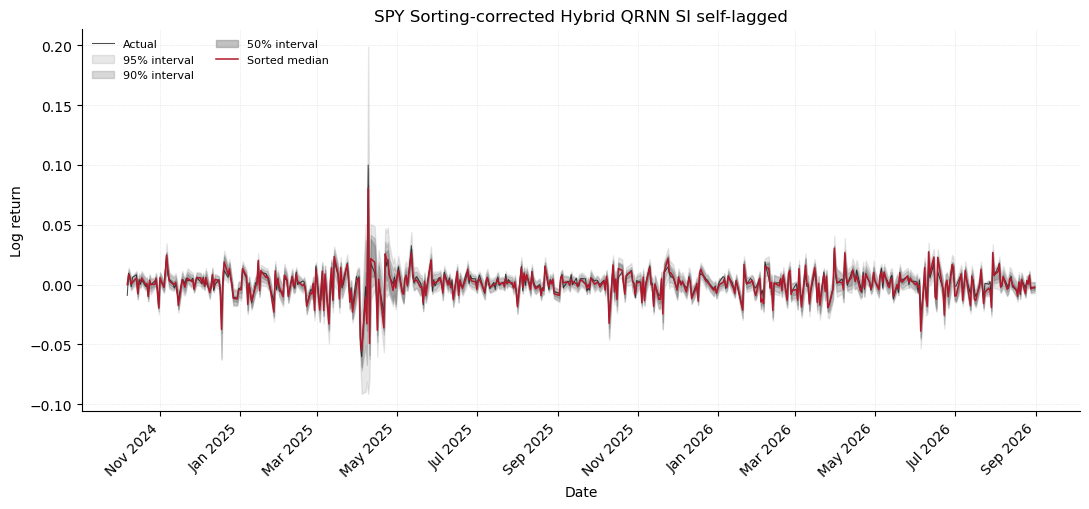

TEST METRICS — SORTING SPY QRNN SI SELF-LAGGED
     alpha  raw_test_nll  sorted_test_nll  raw_hit_rate  sorted_hit_rate    raw_hre  sorted_hre  mean_absolute_adjustment
0.02500000   -3.55074040      -3.53456376    0.01680672       0.01260504 0.00819328  0.01239496                0.00054135
0.05000000   -3.75232659      -3.79597849    0.02731092       0.02941176 0.02268908  0.02058824                0.00046746
0.25000000   -4.07391064      -4.07761484    0.19117647       0.19327731 0.05882353  0.05672269                0.00012903
0.50000000   -4.21583160      -4.21873661    0.44537815       0.44327731 0.05462185  0.05672269                0.00006630
0.75000000   -4.13346690      -4.16094054    0.73529412       0.73739496 0.01470588  0.01260504                0.00011316
0.95000000   -3.83513893      -3.93624727    0.98319328       0.97689076 0.03319328  0.02689076                0.00069163
0.97500000   -3.71083958      -3.69991864    0.98529412       0.99159664 0.01029412  0.01659664    

In [13]:
# ============================================================
# CROSSOVER METHOD: POST-PROCESSING SORTING
# SPY HYBRID QRNN SI — SELF-LAGGED
# Uses saved unrestricted forecasts; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 1. Settings and saved original results
# ------------------------------------------------------------

SORTING_LEVELS = np.array([
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
], dtype=float)

ORIGINAL_MODEL_NAME = "spy_qrnn_si_self"

ORIGINAL_RESULT_DIR = (
    Path("spy_original_tuning_results")
    / ORIGINAL_MODEL_NAME
)

SORTING_OUTPUT_DIR = (
    Path("spy_sorting_crossover_results")
    / ORIGINAL_MODEL_NAME
)
SORTING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

predictions_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_predictions.csv"
)
metrics_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_metrics.csv"
)

if not predictions_path.exists():
    raise FileNotFoundError(
        f"Original prediction file not found: {predictions_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )

if not metrics_path.exists():
    raise FileNotFoundError(
        f"Original metric file not found: {metrics_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )


# ------------------------------------------------------------
# 2. Load unrestricted forecasts and sort each date independently
# ------------------------------------------------------------

raw_table = pd.read_csv(predictions_path, parse_dates=["Date"])
original_metrics = pd.read_csv(metrics_path)

quantile_columns = [f"q_{alpha:.3f}" for alpha in SORTING_LEVELS]
missing_columns = [
    column for column in ["Date", "Actual", *quantile_columns]
    if column not in raw_table.columns
]

if missing_columns:
    raise ValueError(
        "Missing columns in saved prediction file: "
        + ", ".join(missing_columns)
    )

raw_forecasts = raw_table[quantile_columns].to_numpy(dtype=float)
sorted_forecasts = np.sort(raw_forecasts, axis=1)
actual = raw_table["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(raw_table["Date"])

if len(original_metrics) != len(SORTING_LEVELS):
    raise ValueError("The saved metric file must contain all seven levels.")

sigma_by_level = (
    original_metrics
    .assign(alpha=original_metrics["alpha"].astype(float))
    .set_index("alpha")["Sigma"]
)


# ------------------------------------------------------------
# 3. Recalculate ALD NLL, coverage and HRE after sorting
# ------------------------------------------------------------

def ald_nll_by_observation(y, forecast, sigma, alpha):
    sigma = max(float(sigma), np.finfo(float).eps)
    residual = y - forecast
    indicator = (residual < 0.0).astype(float)
    check_loss = residual * (float(alpha) - indicator)

    return (
        -np.log(float(alpha) * (1.0 - float(alpha)))
        + np.log(sigma)
        + check_loss / sigma
    )


metric_records = []
raw_nll_columns = []
sorted_nll_columns = []

for level_index, alpha in enumerate(SORTING_LEVELS):
    sigma = float(sigma_by_level.loc[alpha])
    raw_forecast = raw_forecasts[:, level_index]
    sorted_forecast = sorted_forecasts[:, level_index]

    raw_nll = ald_nll_by_observation(
        actual, raw_forecast, sigma, alpha
    )
    sorted_nll = ald_nll_by_observation(
        actual, sorted_forecast, sigma, alpha
    )

    raw_hit_rate = float(np.mean(actual <= raw_forecast))
    sorted_hit_rate = float(np.mean(actual <= sorted_forecast))

    raw_nll_columns.append(raw_nll)
    sorted_nll_columns.append(sorted_nll)

    metric_records.append({
        "alpha": alpha,
        "raw_test_nll": float(np.mean(raw_nll)),
        "sorted_test_nll": float(np.mean(sorted_nll)),
        "raw_hit_rate": raw_hit_rate,
        "sorted_hit_rate": sorted_hit_rate,
        "raw_hre": abs(raw_hit_rate - alpha),
        "sorted_hre": abs(sorted_hit_rate - alpha),
        "mean_absolute_adjustment": float(
            np.mean(np.abs(sorted_forecast - raw_forecast))
        ),
    })

sorting_metrics = pd.DataFrame(metric_records)
raw_nll_matrix = np.column_stack(raw_nll_columns)
sorted_nll_matrix = np.column_stack(sorted_nll_columns)


# ------------------------------------------------------------
# 4. Crossover and adjustment diagnostics
# ------------------------------------------------------------

def crossover_summary(forecast_matrix):
    pair_records = []
    total = 0
    tail = 0

    for pair_index in range(len(SORTING_LEVELS) - 1):
        violation_mask = (
            forecast_matrix[:, pair_index]
            > forecast_matrix[:, pair_index + 1]
        )
        count = int(violation_mask.sum())
        is_tail = pair_index in {0, len(SORTING_LEVELS) - 2}
        total += count
        if is_tail:
            tail += count

        pair_records.append({
            "lower_alpha": SORTING_LEVELS[pair_index],
            "upper_alpha": SORTING_LEVELS[pair_index + 1],
            "violations": count,
            "violation_rate": count / len(forecast_matrix),
            "tail_pair": is_tail,
        })

    return total, tail, pd.DataFrame(pair_records)


raw_crossover, raw_tail, raw_pair_table = crossover_summary(
    raw_forecasts
)
sorted_crossover, sorted_tail, sorted_pair_table = crossover_summary(
    sorted_forecasts
)

adjustment_matrix = sorted_forecasts - raw_forecasts
changed_rows = np.any(
    ~np.isclose(adjustment_matrix, 0.0, atol=1e-12),
    axis=1,
)


# ------------------------------------------------------------
# 5. Save all sorting results
# ------------------------------------------------------------

sorted_prediction_table = pd.DataFrame({
    "Date": dates,
    "Actual": actual,
})

for level_index, alpha in enumerate(SORTING_LEVELS):
    sorted_prediction_table[f"raw_q_{alpha:.3f}"] = (
        raw_forecasts[:, level_index]
    )
    sorted_prediction_table[f"sorted_q_{alpha:.3f}"] = (
        sorted_forecasts[:, level_index]
    )

sorting_nll_by_date = pd.DataFrame({"Date": dates})
for level_index, alpha in enumerate(SORTING_LEVELS):
    sorting_nll_by_date[f"raw_nll_{alpha:.3f}"] = (
        raw_nll_matrix[:, level_index]
    )
    sorting_nll_by_date[f"sorted_nll_{alpha:.3f}"] = (
        sorted_nll_matrix[:, level_index]
    )
sorting_nll_by_date["raw_average_nll"] = raw_nll_matrix.mean(axis=1)
sorting_nll_by_date["sorted_average_nll"] = (
    sorted_nll_matrix.mean(axis=1)
)

sorting_summary = pd.DataFrame([{
    "model": ORIGINAL_MODEL_NAME,
    "test_T": len(actual),
    "raw_average_nll": sorting_metrics["raw_test_nll"].mean(),
    "sorted_average_nll": sorting_metrics["sorted_test_nll"].mean(),
    "raw_average_hre": sorting_metrics["raw_hre"].mean(),
    "sorted_average_hre": sorting_metrics["sorted_hre"].mean(),
    "raw_crossover": raw_crossover,
    "sorted_crossover": sorted_crossover,
    "raw_tail": raw_tail,
    "sorted_tail": sorted_tail,
    "changed_observations": int(changed_rows.sum()),
    "mean_absolute_adjustment": float(
        np.mean(np.abs(adjustment_matrix))
    ),
    "maximum_absolute_adjustment": float(
        np.max(np.abs(adjustment_matrix))
    ),
}])

sorted_prediction_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_predictions.csv",
    index=False,
)
sorting_metrics.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_metrics.csv",
    index=False,
)
sorting_nll_by_date.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_nll_by_date.csv",
    index=False,
)
raw_pair_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_raw_crossovers.csv",
    index=False,
)
sorted_pair_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_crossovers.csv",
    index=False,
)
sorting_summary.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 6. Bitcoin-style plot: black actual, red median, grey bands
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 0],
    sorted_forecasts[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 1],
    sorted_forecasts[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 2],
    sorted_forecasts[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    sorted_forecasts[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="Sorted median",
)

ax.set(
    title="SPY Sorting-corrected Hybrid QRNN SI self-lagged",
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")

fig.tight_layout()

plot_path = SORTING_OUTPUT_DIR / (
    f"sorting_{ORIGINAL_MODEL_NAME}_predictions.png"
)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 7. Report
# ------------------------------------------------------------

print("=" * 79)
print("TEST METRICS — SORTING SPY QRNN SI SELF-LAGGED")
print("=" * 79)
print(sorting_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\n" + "=" * 79)
print("SUMMARY")
print("=" * 79)
print(f"Raw average NLL:         {sorting_summary.loc[0, 'raw_average_nll']:.6f}")
print(f"Sorted average NLL:      {sorting_summary.loc[0, 'sorted_average_nll']:.6f}")
print(f"Raw average HRE:         {sorting_summary.loc[0, 'raw_average_hre']:.6f}")
print(f"Sorted average HRE:      {sorting_summary.loc[0, 'sorted_average_hre']:.6f}")
print(f"Raw crossover:           {raw_crossover}")
print(f"Sorted crossover:        {sorted_crossover}")
print(f"Raw tail violations:     {raw_tail}")
print(f"Sorted tail violations:  {sorted_tail}")
print(f"Changed observations:    {int(changed_rows.sum())}/{len(actual)}")
print(
    "Mean adjustment:         "
    f"{np.mean(np.abs(adjustment_matrix)):.8f}"
)
print(
    "Maximum adjustment:      "
    f"{np.max(np.abs(adjustment_matrix)):.8f}"
)
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll sorting results saved under:\n{SORTING_OUTPUT_DIR}")


## Crossover - PAVA


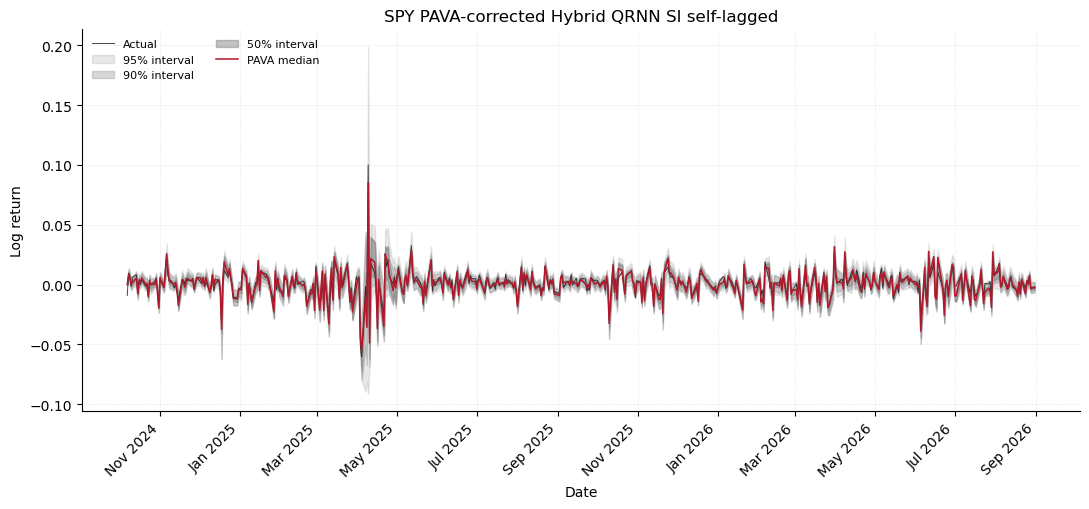

TEST METRICS — EQUAL-WEIGHT PAVA SPY QRNN SI SELF-LAGGED
     alpha     raw_nll    pava_nll  raw_pinball  pava_pinball  raw_hit_rate  pava_hit_rate    raw_hre   pava_hre  mean_absolute_adjustment
0.02500000 -3.55074040 -3.55211578   0.00025554    0.00025514    0.01680672     0.01260504 0.00819328 0.01239496                0.00027163
0.05000000 -3.75232659 -3.77927830   0.00040905    0.00039723    0.02731092     0.02731092 0.02268908 0.02268908                0.00026972
0.25000000 -4.07391064 -4.06856571   0.00117252    0.00117856    0.19117647     0.19117647 0.05882353 0.05882353                0.00003618
0.50000000 -4.21583160 -4.22067063   0.00132009    0.00131192    0.44537815     0.44537815 0.05462185 0.05462185                0.00004458
0.75000000 -4.13346690 -4.14907350   0.00109258    0.00107262    0.73529412     0.73739496 0.01470588 0.01260504                0.00006360
0.95000000 -3.83513893 -3.87770513   0.00036895    0.00034936    0.98319328     0.98319328 0.03319328 0.03319

In [16]:
# ============================================================
# CROSSOVER METHOD: EQUAL-WEIGHT PAVA
# SPY HYBRID QRNN SI — SELF-LAGGED
# Uses saved unrestricted forecasts; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 1. Settings and saved original results
# ------------------------------------------------------------

PAVA_LEVELS = np.array([
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
], dtype=float)

ORIGINAL_MODEL_NAME = "spy_qrnn_si_self"

ORIGINAL_RESULT_DIR = (
    Path("spy_original_tuning_results")
    / ORIGINAL_MODEL_NAME
)

PAVA_OUTPUT_DIR = (
    Path("spy_pava_crossover_results")
    / ORIGINAL_MODEL_NAME
)
PAVA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

predictions_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_predictions.csv"
)
metrics_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_metrics.csv"
)

if not predictions_path.exists():
    raise FileNotFoundError(
        f"Original prediction file not found: {predictions_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )

if not metrics_path.exists():
    raise FileNotFoundError(
        f"Original metric file not found: {metrics_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )


# ------------------------------------------------------------
# 2. Equal-weight PAVA
# ------------------------------------------------------------

def equal_weight_pava(values):
    """Least-squares projection onto a nondecreasing sequence."""
    values = np.asarray(values, dtype=float)

    block_values = []
    block_weights = []
    block_starts = []
    block_ends = []

    for index, value in enumerate(values):
        block_values.append(float(value))
        block_weights.append(1.0)
        block_starts.append(index)
        block_ends.append(index)

        while (
            len(block_values) >= 2
            and block_values[-2] > block_values[-1]
        ):
            merged_weight = block_weights[-2] + block_weights[-1]
            merged_value = (
                block_weights[-2] * block_values[-2]
                + block_weights[-1] * block_values[-1]
            ) / merged_weight
            merged_start = block_starts[-2]
            merged_end = block_ends[-1]

            block_values[-2:] = [merged_value]
            block_weights[-2:] = [merged_weight]
            block_starts[-2:] = [merged_start]
            block_ends[-2:] = [merged_end]

    projected = np.empty_like(values, dtype=float)
    for value, start, end in zip(
        block_values,
        block_starts,
        block_ends,
    ):
        projected[start:end + 1] = value

    return projected


# ------------------------------------------------------------
# 3. Load unrestricted forecasts and project every test date
# ------------------------------------------------------------

raw_table = pd.read_csv(predictions_path, parse_dates=["Date"])
original_metrics = pd.read_csv(metrics_path)

quantile_columns = [f"q_{alpha:.3f}" for alpha in PAVA_LEVELS]
missing_columns = [
    column for column in ["Date", "Actual", *quantile_columns]
    if column not in raw_table.columns
]

if missing_columns:
    raise ValueError(
        "Missing columns in saved prediction file: "
        + ", ".join(missing_columns)
    )

raw_forecasts = raw_table[quantile_columns].to_numpy(dtype=float)
pava_forecasts = np.vstack([
    equal_weight_pava(row)
    for row in raw_forecasts
])

actual = raw_table["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(raw_table["Date"])

if len(original_metrics) != len(PAVA_LEVELS):
    raise ValueError("The saved metric file must contain all seven levels.")

sigma_by_level = (
    original_metrics
    .assign(alpha=original_metrics["alpha"].astype(float))
    .set_index("alpha")["Sigma"]
)


# ------------------------------------------------------------
# 4. Recalculate ALD NLL, pinball loss, coverage and HRE
# ------------------------------------------------------------

def pinball_by_observation(y, forecast, alpha):
    residual = y - forecast
    indicator = (residual < 0.0).astype(float)
    return residual * (float(alpha) - indicator)


def ald_nll_by_observation(y, forecast, sigma, alpha):
    sigma = max(float(sigma), np.finfo(float).eps)
    return (
        -np.log(float(alpha) * (1.0 - float(alpha)))
        + np.log(sigma)
        + pinball_by_observation(y, forecast, alpha) / sigma
    )


metric_records = []
raw_nll_columns = []
pava_nll_columns = []

for level_index, alpha in enumerate(PAVA_LEVELS):
    sigma = float(sigma_by_level.loc[alpha])
    raw_forecast = raw_forecasts[:, level_index]
    pava_forecast = pava_forecasts[:, level_index]

    raw_pinball = pinball_by_observation(actual, raw_forecast, alpha)
    pava_pinball = pinball_by_observation(actual, pava_forecast, alpha)
    raw_nll = ald_nll_by_observation(
        actual, raw_forecast, sigma, alpha
    )
    pava_nll = ald_nll_by_observation(
        actual, pava_forecast, sigma, alpha
    )

    raw_hit_rate = float(np.mean(actual <= raw_forecast))
    pava_hit_rate = float(np.mean(actual <= pava_forecast))

    raw_nll_columns.append(raw_nll)
    pava_nll_columns.append(pava_nll)

    metric_records.append({
        "alpha": alpha,
        "raw_nll": float(np.mean(raw_nll)),
        "pava_nll": float(np.mean(pava_nll)),
        "raw_pinball": float(np.mean(raw_pinball)),
        "pava_pinball": float(np.mean(pava_pinball)),
        "raw_hit_rate": raw_hit_rate,
        "pava_hit_rate": pava_hit_rate,
        "raw_hre": abs(raw_hit_rate - alpha),
        "pava_hre": abs(pava_hit_rate - alpha),
        "mean_absolute_adjustment": float(
            np.mean(np.abs(pava_forecast - raw_forecast))
        ),
    })

pava_metrics = pd.DataFrame(metric_records)
raw_nll_matrix = np.column_stack(raw_nll_columns)
pava_nll_matrix = np.column_stack(pava_nll_columns)


# ------------------------------------------------------------
# 5. Crossover and adjustment diagnostics
# ------------------------------------------------------------

def crossover_summary(forecast_matrix):
    pair_records = []
    total = 0
    tail = 0

    for pair_index in range(len(PAVA_LEVELS) - 1):
        violation_mask = (
            forecast_matrix[:, pair_index]
            > forecast_matrix[:, pair_index + 1]
        )
        count = int(violation_mask.sum())
        is_tail = pair_index in {0, len(PAVA_LEVELS) - 2}
        total += count
        if is_tail:
            tail += count

        pair_records.append({
            "lower_alpha": PAVA_LEVELS[pair_index],
            "upper_alpha": PAVA_LEVELS[pair_index + 1],
            "violations": count,
            "violation_rate": count / len(forecast_matrix),
            "tail_pair": is_tail,
        })

    return total, tail, pd.DataFrame(pair_records)


raw_crossover, raw_tail, raw_pair_table = crossover_summary(
    raw_forecasts
)
pava_crossover, pava_tail, pava_pair_table = crossover_summary(
    pava_forecasts
)

adjustment_matrix = pava_forecasts - raw_forecasts
changed_rows = np.any(
    ~np.isclose(adjustment_matrix, 0.0, atol=1e-12),
    axis=1,
)


# ------------------------------------------------------------
# 6. Save all PAVA results
# ------------------------------------------------------------

pava_prediction_table = pd.DataFrame({
    "Date": dates,
    "Actual": actual,
})

for level_index, alpha in enumerate(PAVA_LEVELS):
    pava_prediction_table[f"raw_q_{alpha:.3f}"] = (
        raw_forecasts[:, level_index]
    )
    pava_prediction_table[f"pava_q_{alpha:.3f}"] = (
        pava_forecasts[:, level_index]
    )

pava_nll_by_date = pd.DataFrame({"Date": dates})
for level_index, alpha in enumerate(PAVA_LEVELS):
    pava_nll_by_date[f"raw_nll_{alpha:.3f}"] = (
        raw_nll_matrix[:, level_index]
    )
    pava_nll_by_date[f"pava_nll_{alpha:.3f}"] = (
        pava_nll_matrix[:, level_index]
    )
pava_nll_by_date["raw_average_nll"] = raw_nll_matrix.mean(axis=1)
pava_nll_by_date["pava_average_nll"] = pava_nll_matrix.mean(axis=1)

pava_summary = pd.DataFrame([{
    "model": ORIGINAL_MODEL_NAME,
    "test_T": len(actual),
    "raw_average_nll": pava_metrics["raw_nll"].mean(),
    "pava_average_nll": pava_metrics["pava_nll"].mean(),
    "raw_average_hre": pava_metrics["raw_hre"].mean(),
    "pava_average_hre": pava_metrics["pava_hre"].mean(),
    "raw_total_pinball": pava_metrics["raw_pinball"].sum(),
    "pava_total_pinball": pava_metrics["pava_pinball"].sum(),
    "raw_crossover": raw_crossover,
    "pava_crossover": pava_crossover,
    "raw_tail": raw_tail,
    "pava_tail": pava_tail,
    "changed_observations": int(changed_rows.sum()),
    "mean_absolute_adjustment": float(
        np.mean(np.abs(adjustment_matrix))
    ),
    "maximum_absolute_adjustment": float(
        np.max(np.abs(adjustment_matrix))
    ),
}])

pava_prediction_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_predictions.csv",
    index=False,
)
pava_metrics.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_metrics.csv",
    index=False,
)
pava_nll_by_date.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_nll_by_date.csv",
    index=False,
)
raw_pair_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_raw_crossovers.csv",
    index=False,
)
pava_pair_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_crossovers.csv",
    index=False,
)
pava_summary.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 7. Bitcoin-style plot: black actual, red median, grey bands
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 0],
    pava_forecasts[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 1],
    pava_forecasts[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 2],
    pava_forecasts[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    pava_forecasts[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="PAVA median",
)

ax.set(
    title="SPY PAVA-corrected Hybrid QRNN SI self-lagged",
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")

fig.tight_layout()

plot_path = PAVA_OUTPUT_DIR / (
    f"pava_{ORIGINAL_MODEL_NAME}_predictions.png"
)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 8. Report
# ------------------------------------------------------------

print("=" * 79)
print("TEST METRICS — EQUAL-WEIGHT PAVA SPY QRNN SI SELF-LAGGED")
print("=" * 79)
print(pava_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\n" + "=" * 79)
print("SUMMARY")
print("=" * 79)
print(f"Raw average NLL:       {pava_summary.loc[0, 'raw_average_nll']:.6f}")
print(f"PAVA average NLL:      {pava_summary.loc[0, 'pava_average_nll']:.6f}")
print(f"Raw average HRE:       {pava_summary.loc[0, 'raw_average_hre']:.6f}")
print(f"PAVA average HRE:      {pava_summary.loc[0, 'pava_average_hre']:.6f}")
print(f"Raw total pinball:     {pava_summary.loc[0, 'raw_total_pinball']:.8f}")
print(f"PAVA total pinball:    {pava_summary.loc[0, 'pava_total_pinball']:.8f}")
print(f"Raw crossover:         {raw_crossover}")
print(f"PAVA crossover:        {pava_crossover}")
print(f"Raw tail violations:   {raw_tail}")
print(f"PAVA tail violations:  {pava_tail}")
print(f"Changed observations:  {int(changed_rows.sum())}/{len(actual)}")
print(
    "Mean adjustment:       "
    f"{np.mean(np.abs(adjustment_matrix)):.8f}"
)
print(
    "Maximum adjustment:    "
    f"{np.max(np.abs(adjustment_matrix)):.8f}"
)
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll PAVA results saved under:\n{PAVA_OUTPUT_DIR}")
